In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df=pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\AMDARI\Finlora Finance\notebook\cleaned_data2.csv")

In [48]:
df.head(1)

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd,transaction_id,timestamp,...,is_fraud,Standardized_Description,Fallback_Merchant,year,month,day,exchange_rate,amount_in_GBP,amount_in_USD,is_same_day
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,FLR250216186265,2025-02-16 14:55:35,...,0,CNP PURCHASE - BOLT,Bolt,2022,August,28,0.00056,47.17048,61.321624,0


In [49]:
print(df.columns)

Index(['account_id', 'account_holder_name', 'account_type', 'home_country',
       'currency', 'kyc_tier', 'account_created_date',
       'personal_spend_baseline_usd', 'transaction_id', 'timestamp',
       'day_of_week', 'hour_of_day', 'description', 'merchant_name',
       'merchant_category', 'channel', 'amount', 'amount_to_avg_ratio',
       'avg_transaction_amount_30d', 'transaction_velocity_1h',
       'transaction_country', 'is_cross_border', 'device_id', 'is_new_device',
       'account_age_days', 'status', 'is_fraud', 'Standardized_Description',
       'Fallback_Merchant', 'year', 'month', 'day', 'exchange_rate',
       'amount_in_GBP', 'amount_in_USD', 'is_same_day'],
      dtype='object')


In [50]:
# Remove irrelevant columns

# 1. Separate target label

y = df['is_fraud']

# 2. columns to drop from features
columns_to_drop = [
    'is_fraud',                  # Drop the target label from X
    'day',
    'account_id', 'account_holder_name', 'transaction_id', 'device_id', # Identifiers
    'timestamp', 'account_created_date', # Raw dates
    'amount', 'amount_in_GBP', 'exchange_rate', # Redundant financial info
    'description', 'Standardized_Description', 'merchant_name', 'Fallback_Merchant', # Raw text
    'status' # High risk for target leakage
]

# 3. clean feature set
x = df.drop(columns=columns_to_drop, errors='ignore')


In [51]:
print(x.columns)

Index(['account_type', 'home_country', 'currency', 'kyc_tier',
       'personal_spend_baseline_usd', 'day_of_week', 'hour_of_day',
       'merchant_category', 'channel', 'amount_to_avg_ratio',
       'avg_transaction_amount_30d', 'transaction_velocity_1h',
       'transaction_country', 'is_cross_border', 'is_new_device',
       'account_age_days', 'year', 'month', 'amount_in_USD', 'is_same_day'],
      dtype='object')


In [52]:
x.head(1)

,account_type,home_country,currency,kyc_tier,personal_spend_baseline_usd,day_of_week,hour_of_day,merchant_category,channel,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,is_cross_border,is_new_device,account_age_days,year,month,amount_in_USD,is_same_day
0,Individual,NG,NGN,Tier3_Enhanced,63.23,Sunday,14,Travel,Card Not Present,9.21,9143.33,0.0,NG,0,-1,903,2022,August,61.321624,0


In [53]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install scikit-learn lightgbm


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [54]:
# encode and scale the data

#Split into Train and Test sets to prevent data leakage during encoding
# test size = 0.25 as required by the case study (work flow, step 5)



from sklearn.model_selection import train_test_split

# 1. Isolate target variable and features
y =df['is_fraud']
X = df[['account_type', 'home_country', 'currency', 'kyc_tier',
       'personal_spend_baseline_usd', 'day_of_week', 'hour_of_day',
       'merchant_category', 'channel', 'amount_to_avg_ratio',
       'avg_transaction_amount_30d', 'transaction_velocity_1h',
       'transaction_country', 'is_cross_border', 'is_new_device',
       'account_age_days', 'year', 'month', 'amount_in_USD', 'is_same_day']]

# 2. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [55]:
# 3. Encode and scale

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# Group column types based on your dataset properties
ohe_cols = ['account_type', 'currency', 'channel', 'kyc_tier', 'merchant_category', 'home_country', 'transaction_country']
ordinal_cols = ['day_of_week', 'month']

# Create encoder transformer
encoder_transformer = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ohe_cols),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)

# 1. Transform text columns into numbers
X_train_encoded = encoder_transformer.fit_transform(X_train, y_train)
X_test_encoded = encoder_transformer.transform(X_test)

# 2. Scale the unified numeric matrix
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"✅ Preprocessing successful! Final matrix shape: {X_train_scaled.shape}")


✅ Preprocessing successful! Final matrix shape: (94500, 46)


In [56]:
print(X_train_encoded)

[[1.00000000e+00 0.00000000e+00 1.00000000e+00 ... 2.02400000e+03
  5.45703558e+01 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00 1.00000000e+00 ... 2.02400000e+03
  8.18053600e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.02300000e+03
  1.57257100e+03 0.00000000e+00]
 ...
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.02400000e+03
  5.32832300e+01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 2.02400000e+03
  6.14593856e+02 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.02600000e+03
  3.30330000e+01 1.00000000e+00]]


In [57]:
# Handle class imbalance

%pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [58]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training class distribution: {Counter(y_train)}")

# Initialize SMOTE (random_state ensures results are reproducible)
smote = SMOTE(random_state=42)

# Resample ONLY the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced training class distribution: {Counter(y_train_balanced)}")


Original training class distribution: Counter({0: 91986, 1: 2514})
Balanced training class distribution: Counter({0: 91986, 1: 91986})


In [59]:
# train model,

from sklearn.linear_model import LogisticRegression

# Initialize the model 

# max_iter=1000 ensures the mathematical solver has plenty of room to converge
model_balanced = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on newly balanced training datasets

model_balanced.fit(X_train_balanced, y_train_balanced)


print("🎯 Model training on balanced data complete!")



🎯 Model training on balanced data complete!


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predict the outcomes for your test set
y_pred_balanced = model_balanced.predict(X_test_scaled)

# 2. Print evaluation metrics
print("📊 --- CLASSIFICATION REPORT (SMOTE) ---")
print(classification_report(y_test, y_pred_balanced))

print("\n🧩 --- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_balanced))


📊 --- CLASSIFICATION REPORT (SMOTE) ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     30662
           1       0.38      0.79      0.52       838

    accuracy                           0.96     31500
   macro avg       0.69      0.88      0.75     31500
weighted avg       0.98      0.96      0.97     31500


🧩 --- CONFUSION MATRIX ---
[[29602  1060]
 [  179   659]]


This model is stopping roughly 79% (recall) of fraud losses. It successfully caught 659 out of 838 actual fraud cases.

However, the precision was low (0.38%). Out of 1,719 total transactions flagged as fraud, 1,060 were completely legitimate customers (false positives). It is falsely accusing or blocking nearly 2 loyal customers for every 1 actual fraudster caught.

179 fraud cases still slipped through completely undetected (false negatives).

With an F1 score of 0.52, the model has moderate performance.

In [61]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve

# 1. Get the predicted probabilities for the positive class (Class 1)
# (Ensure your model supports predict_proba; most sklearn models do)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate the exact ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_balanced)
print(f"🏅 --- ROC-AUC SCORE ---")
print(f"ROC-AUC: {roc_auc:.4f}\n")

# 3. Get precision and recall values across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_balanced)

print(f"📈 --- TUNABLE OPERATING POINTS ---")
# 4. Find the precision at specific target recall points (70%, 80%, 90%)
target_recalls = [0.70, 0.80, 0.90]

for target in target_recalls:
    # Find the index where the recall is closest to our target
    # (recalls array is sorted in descending order)
    idx = np.where(recalls <= target)[0][0] 
    
    corresponding_precision = precisions[idx]
    
    # The thresholds array is 1 element shorter than precision/recall
    corresponding_threshold = thresholds[idx] if idx < len(thresholds) else thresholds[-1]
    
    print(f"Target Recall: {target*100:.0f}%")
    print(f"  -> Resulting Precision: {corresponding_precision*100:.2f}%")
    print(f"  -> Required Probability Threshold: {corresponding_threshold:.4f}\n")


🏅 --- ROC-AUC SCORE ---
ROC-AUC: 0.9338

📈 --- TUNABLE OPERATING POINTS ---
Target Recall: 70%
  -> Resulting Precision: 63.63%
  -> Required Probability Threshold: 0.7274

Target Recall: 80%
  -> Resulting Precision: 34.63%
  -> Required Probability Threshold: 0.4734

Target Recall: 90%
  -> Resulting Precision: 10.07%
  -> Required Probability Threshold: 0.2366



An ROC-AUC score of 0.9338 means the model has an outstanding discrimination power, showing an exceptional ability to rank true fraudulent transactions higher than legitimate ones.

At 70% recall, it catches less fraud, but drastically reduce customer friction, (precision 63.63%). Ideal if you have a small review team.
If a transaction receives a probability score of >= 0.7274, it will be classified as fraud.

At 80% recall, there is moderate fraud capture and manageable cutomer friction.
If a transaction receives a probability score of >= 0.4734, it will be classified as fraud.

At 90% recall, almost all fraud cases are caught, but it blocks 9 legitimate users for every 1 thief. Explodes operational costs. 

Random forest model

In [62]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# 1. Initialize Random Forest WITHOUT SMOTE
# Runs directly on your scaled, un-resampled data matrices
model_rf_raw_subsample = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced_subsample',  # Calculates weights dynamically per tree bootstrap
    random_state=42,
    n_jobs=-1
)

# 2. Train using the scaled training partition
model_rf_raw_subsample.fit(X_train_scaled, y_train)

# 3. Predict on the held-out test partition
y_pred_rf_raw = model_rf_raw_subsample.predict(X_test_scaled)
y_prob_rf_raw = model_rf_raw_subsample.predict_proba(X_test_scaled)[:, 1]

# 4. Print core evaluation metrics
print("📊 --- CLASSIFICATION REPORT (RAW DATA + BALANCED SUBSAMPLE) ---")
print(classification_report(y_test, y_pred_rf_raw))

print("\n🧩 --- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_rf_raw))

roc_auc_rf_raw = roc_auc_score(y_test, y_prob_rf_raw)
print(f"\n🏅 --- ROC-AUC SCORE: {roc_auc_rf_raw:.4f} ---")

# 5. Extract fixed operational thresholds for the risk team
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf_raw)
print("\n📈 --- OPERATIONAL METRICS FOR THE RISK TEAM ---")

for target in [0.70, 0.80, 0.90]:
    # Find all indices where recall is less than or equal to the target
    matching_indices = np.where(recalls <= target)[0]
    
    if len(matching_indices) > 0:
        # Get the first index value where the condition is met
        idx_val = matching_indices[0]
        corresponding_precision = precisions[idx_val]
        
        # Safely align threshold index (thresholds array is 1 element shorter)
        thresh_idx = max(0, idx_val - 1)
        corresponding_threshold = thresholds[thresh_idx] if thresh_idx < len(thresholds) else thresholds[-1]
        
        print(f"Target Recall: {target*100:.0f}%")
        print(f"  -> Resulting Precision: {corresponding_precision*100:.2f}%")
        print(f"  -> Score Threshold: {corresponding_threshold:.4f}\n")
    else:
        print(f"Target Recall: {target*100:.0f}% -> No matching threshold found.\n")


📊 --- CLASSIFICATION REPORT (RAW DATA + BALANCED SUBSAMPLE) ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     30662
           1       0.34      0.82      0.48       838

    accuracy                           0.95     31500
   macro avg       0.67      0.89      0.73     31500
weighted avg       0.98      0.95      0.96     31500


🧩 --- CONFUSION MATRIX ---
[[29310  1352]
 [  149   689]]

🏅 --- ROC-AUC SCORE: 0.9323 ---

📈 --- OPERATIONAL METRICS FOR THE RISK TEAM ---
Target Recall: 70%
  -> Resulting Precision: 57.56%
  -> Score Threshold: 0.7130

Target Recall: 80%
  -> Resulting Precision: 40.63%
  -> Score Threshold: 0.5809

Target Recall: 90%
  -> Resulting Precision: 12.24%
  -> Score Threshold: 0.2323



At default thresholds, the Random Forest model is more aggressive. It moves the default Recall from 79% to 82% (+30 fraud cases caught). However, to catch those 30 extra fraudsters, it falsely accuses 292 more legitimate customers (1,352 vs 1,060).
The model trades ~10 false positives for every 1 extra fraud case caught.

•For a low-friction system (Target 70% Recall): Logistic regression model will perform better. It yields a 63.63% precision compared to the Random Forest's 57.56%.

•For an aggressive system (Target 80% or 90% Recall): Random Forest will perform better. If the thresholds are dropped to catch 80% or 90% of fraud, the Random Forest model holds its precision significantly better than the Logistic Regression (e.g., 40.63% vs 34.63% at the 80% recall mark). However the precision is very low. 

*** While Random Forest is a more complex ensemble algorithm, it failed to deliver a significantly higher ROC-AUC (0.9323 vs. 0.9338). Instead, its complexity caused it to overfit the fraud signature, resulting in a massive spike of 1,352 false positives at its default threshold.
The simpler Logistic Regression model scales its probability outputs much better, making it far more controllable and operationally efficient.


Way forward, here are proposed options

The Random Forest prototype can be discarded at default thresholds unless the goal is to run at an aggressive 80%+ recall footprint.
Deploy the Logistic Regression Model into production at a 0.7274 probability threshold. This instantly achieves a highly optimized system:
• You lock in 63.63% precision, meaning nearly 2 out of every 3 alerts your system flags will be actual, verified fraud.
• Your false positives will drop drastically compared to the default setup, heavily reducing user friction and saving your operations team from alert fatigue.
• You safely intercept 70% of all incoming fraud losses.

to maintain logistic regression

Implement a "Grey Area" Queue: Instead of hard-blocking users at the threshold, route transactions with probabilities between 0.23 and 0.72 to step-up authentication (like SMS 2FA) rather than a flat rejection.

[ Transaction Probability Score ]
       |
       |---> Score >= 0.7274       --> 🔴 BLOCK / CHALLENGE (High Certainty)

       |                               Precision: 63.63% | Catch Rate: 70% of fraud
       |
       |---> Score 0.2366 - 0.7273 --> 🟡 STEPS-UP / MANUAL REVIEW (Grey Area)
       |                               Catches an extra 20% of fraud
       |
       |---> Score < 0.2366        --> 🟢 AUTO-PASS (Safe Zone)
                                       Misses less than 10% of total fraud

1. The Green Zone (Auto-Pass) | Scores < 0.2366
• Action: Instantly approve the transaction.
• Why: By cutting off the bottom tier at the 90% recall threshold, you guarantee that 90% of all fraud is safely kept out of this pool. Legitimate customers experience zero friction.
2. The Grey Zone (Step-Up/Review Queue) | Scores 0.2366 to 0.7273
• Action: Trigger an automated SMS/Email OTP, 2FA prompt, or send to a manual review queue.
• Why: This is where your false positives live. Instead of hard-blocking these users (which causes churn), a soft challenge allows legitimate users to clear themselves instantly while stopping the 20% of fraudsters hiding in this band.
3. The Red Zone (Hard Block) | Scores >= 0.7274
• Action: Hard decline or route straight to automated rejection.
• Why: At this threshold, your SMOTE model hits 63.63% precision. For every 2 transactions flagged here, more than 1 is a verified fraudster. This is a highly efficient operational pool.


Other options 

1. optimise random forest
2. use a different model 

In [63]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# 1. Initialize OPTIMIZED Random Forest WITHOUT SMOTE
# Manual class weights place less aggressive emphasis on fraud, crushing false positives.
model_rf_optimized = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,               # Slightly increased depth allowed due to stricter leaf constraints
    min_samples_leaf=5,         # Prevents individual trees from splitting for noisy outliers
    class_weight={0: 1, 1: 3},  # Manually adjusted weight (Change 3 to 2 if False Positives remain high)
    random_state=42,
    n_jobs=-1
)

# 2. Train using the scaled training partition
model_rf_optimized.fit(X_train_scaled, y_train)

# 3. Predict on the held-out test partition
y_pred_rf_raw = model_rf_optimized.predict(X_test_scaled)
y_prob_rf_raw = model_rf_optimized.predict_proba(X_test_scaled)[:, 1]

# 4. Print core evaluation metrics
print("📊 --- CLASSIFICATION REPORT (RAW DATA + TUNED RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf_raw))

print("\n🧩 --- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_rf_raw))

roc_auc_rf_raw = roc_auc_score(y_test, y_prob_rf_raw)
print(f"\n🏅 --- ROC-AUC SCORE: {roc_auc_rf_raw:.4f} ---")

# 5. Extract fixed operational thresholds for the risk team
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf_raw)
print("\n📈 --- OPERATIONAL METRICS FOR THE RISK TEAM ---")

for target in [0.70, 0.80, 0.90]:
    matching_indices = np.where(recalls <= target)[0]
    if len(matching_indices) > 0:
        idx_val = matching_indices[0]
        corresponding_precision = precisions[idx_val]
        thresh_idx = max(0, idx_val - 1)
        corresponding_threshold = thresholds[thresh_idx] if thresh_idx < len(thresholds) else thresholds[-1]
        
        print(f"Target Recall: {target*100:.0f}%")
        print(f"  -> Resulting Precision: {corresponding_precision*100:.2f}%")
        print(f"  -> Score Threshold: {corresponding_threshold:.4f}\n")
    else:
        print(f"Target Recall: {target*100:.0f}% -> No matching threshold found.\n")


📊 --- CLASSIFICATION REPORT (RAW DATA + TUNED RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     30662
           1       0.79      0.62      0.70       838

    accuracy                           0.99     31500
   macro avg       0.89      0.81      0.84     31500
weighted avg       0.98      0.99      0.98     31500


🧩 --- CONFUSION MATRIX ---
[[30522   140]
 [  316   522]]

🏅 --- ROC-AUC SCORE: 0.9362 ---

📈 --- OPERATIONAL METRICS FOR THE RISK TEAM ---
Target Recall: 70%
  -> Resulting Precision: 64.82%
  -> Score Threshold: 0.3503

Target Recall: 80%
  -> Resulting Precision: 39.57%
  -> Score Threshold: 0.1251

Target Recall: 90%
  -> Resulting Precision: 11.38%
  -> Score Threshold: 0.0351



False alerts plummets by nearly 90% compared to the old Random Forest, and slashes Logistic Regression's false alarms by 86%. Only 140 clean customers will experience friction under default settings. However it allows 316 fraudulent transactions to go unflagged

Try LGBMClassifier

In [64]:
import sys
!{sys.executable} -m pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable


In [65]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install scikit-learn lightgbm


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [66]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# 1. Initialize LightGBM Gradient Booster
# scale_pos_weight optimizes class balance sequentially to keep false alerts low.
model_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=5,         # Softly balances the fraud class ratio without the 'balanced' over-correction
    random_state=42,
    n_jobs=-1
)

# 2. Train using the scaled training partition
model_lgbm.fit(X_train_scaled, y_train)

# 3. Predict on the held-out test partition
y_pred_rf_raw = model_lgbm.predict(X_test_scaled)
y_prob_rf_raw = model_lgbm.predict_proba(X_test_scaled)[:, 1]

# 4. Print core evaluation metrics
print("📊 --- CLASSIFICATION REPORT (RAW DATA + LIGHTGBM BOOSTING) ---")
print(classification_report(y_test, y_pred_rf_raw))

print("\n🧩 --- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_rf_raw))

roc_auc_rf_raw = roc_auc_score(y_test, y_prob_rf_raw)
print(f"\n🏅 --- ROC-AUC SCORE: {roc_auc_rf_raw:.4f} ---")

# 5. Extract fixed operational thresholds for the risk team
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf_raw)
print("\n📈 --- OPERATIONAL METRICS FOR THE RISK TEAM ---")

for target in [0.70, 0.80, 0.90]:
    matching_indices = np.where(recalls <= target)[0]
    if len(matching_indices) > 0:
        idx_val = matching_indices[0]
        corresponding_precision = precisions[idx_val]
        thresh_idx = max(0, idx_val - 1)
        corresponding_threshold = thresholds[thresh_idx] if thresh_idx < len(thresholds) else thresholds[-1]
        
        print(f"Target Recall: {target*100:.0f}%")
        print(f"  -> Resulting Precision: {corresponding_precision*100:.2f}%")
        print(f"  -> Score Threshold: {corresponding_threshold:.4f}\n")
    else:
        print(f"Target Recall: {target*100:.0f}% -> No matching threshold found.\n")


[LightGBM] [Info] Number of positive: 2514, number of negative: 91986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1400
[LightGBM] [Info] Number of data points in the train set: 94500, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.026603 -> initscore=-3.599761
[LightGBM] [Info] Start training from score -3.599761
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
📊 --- CLASSIFICATION REPORT (RAW DATA + LIGHTGBM BOOSTING) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     30662
           1       0.64      0.71      0.67       838

    accuracy                           0.98     31500
   macro avg       0.81      0.85      0.83     31500
weighted avg       0.98      0.98

While the Tuned Random Forest offers the lowest customer friction (140 false positives), it exposes the business to severe financial risk by allowing 316 fraudulent transactions to slip through. LightGBM provides the optimal commercial compromise, recovering 73 more fraudulent transactions than the Tuned Random Forest while still suppressing customer friction by 75% compared to the Original Random Forest baseline (slashing false alarms from 1,352 to 339)

Strategic Evaluation & Recommendation

1. The Winner: LightGBM (The Balanced Middle Ground)
LightGBM is the most viable model for a production environment.
In a real-world scenario, letting 316 fraud events slip (Tuned Random Forest) is usually too financially dangerous, while blocking 1,060+ innocent customers (Logistic Regression/Original RF) destroys user retention. LightGBM hits the balanced middle zone. It clamps down on fraud slippage (down to 243) while maintaining a highly respectable, low-friction threshold of only 339 false alarms.
2. The Fallback: Tuned Random Forest (Only if Customer Experience is King)
Deploy this model only if a single "customer insult" (blocking a VIP or loyal user) costs the company more in long-term lifetime value than the average dollar amount lost to a single fraud instance.
3. The Eliminated: Logistic Regression & Original Random Forest
Both of these models generate over 1,000 false alarms. The operational overhead required for an internal risk team to manually review that many false positives completely cancels out the financial savings of the fraud they catch.

# Feature importance

C:\Users\hp\AppData\Local\Temp\ipykernel_3980\2016905915.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


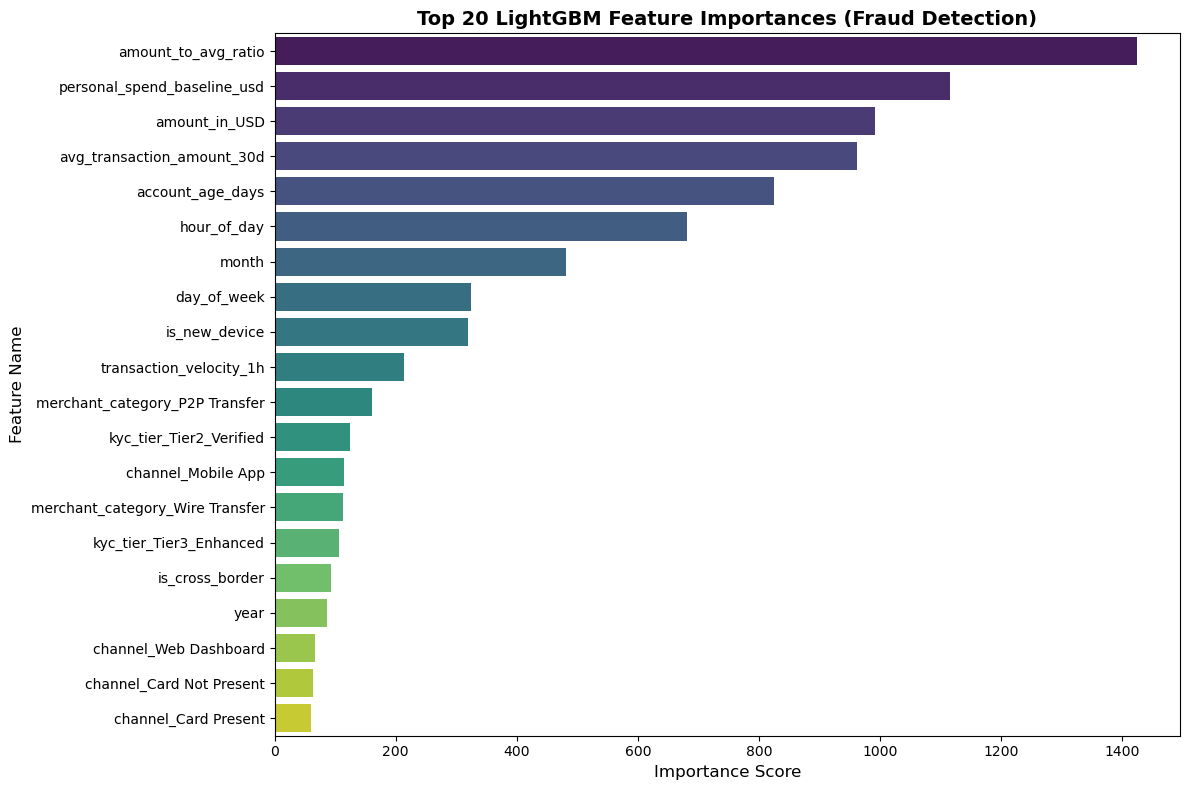

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract the feature names generated by the ColumnTransformer
feature_names = encoder_transformer.get_feature_names_out()

# 2. Pair the extracted feature names with your trained LightGBM importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_lgbm.feature_importances_  # Using your exact model variable name
})

# 3. Clean up the Scikit-learn prefixes for cleaner visual presentation
importance_df['Feature'] = importance_df['Feature'].str.replace('one_hot__', '')
importance_df['Feature'] = importance_df['Feature'].str.replace('ordinal__', '')
importance_df['Feature'] = importance_df['Feature'].str.replace('remainder__', '')

# 4. Sort and isolate the top 20 most important features for fraud detection
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 5. Plot the graph
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 20 LightGBM Feature Importances (Fraud Detection)', fontsize=14, weight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()


• The Heavy Hitters: Numerical indicators related to transaction spikes—specifically amount_to_avg_ratio, personal_spend_baseline_usd, and amount_in_USD—are overwhelmingly the most dominant signals. Your model is heavily relying on how wildly out-of-character a transaction is compared to a user's normal baseline.
• Temporal Patterns: Time and date elements like hour_of_day and month hold massive weight. This indicates strong seasonal or time-of-day behavioral correlations with fraudulent transactions (e.g., high-risk spikes in the middle of the night).
• Categorical Sub-features: You can see your OneHotEncoder perfectly at work down at the bottom! Instead of just saying merchant_category, it is isolating specific slices like merchant_category_P2P Transfer and merchant_category_Wire Transfer, showing that peer-to-peer and wire vectors are much more critical to the model than other merchant types.


In [68]:
!pip install shap

In [69]:
%pip install shap


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



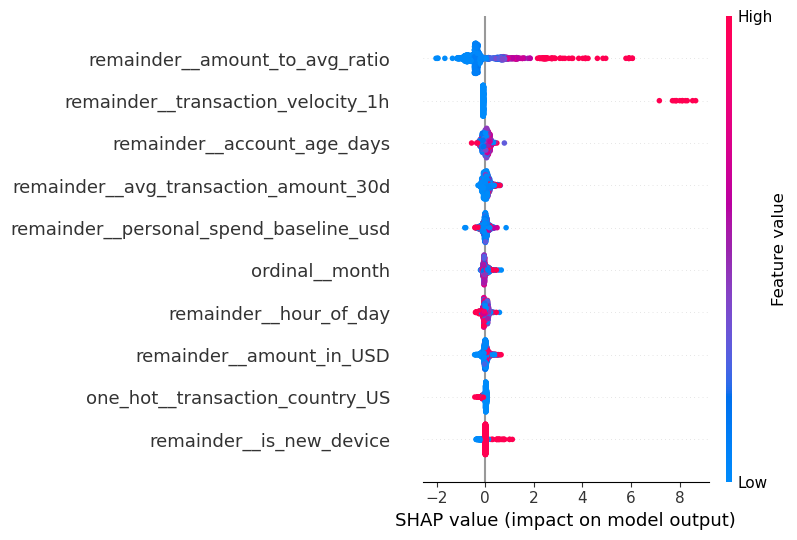

In [71]:
import shap

# 1. Initialize the SHAP TreeExplainer on your trained LightGBM model
explainer = shap.TreeExplainer(model_lgbm)

# 2. Calculate SHAP values for the test partition 
X_sample = X_test_scaled[:1000]
shap_values = explainer(X_sample)

# 3. Create the SHAP summary plot mapped with clean feature names
# FIX: Remove the "[:, :, 1]" slice. Pass shap_values directly.
shap.summary_plot(
    shap_values, 
    features=X_sample, 
    feature_names=encoder_transformer.get_feature_names_out(),
    max_display=10
)


SHAP analysis confirms that fraud risk is highly sensitive to abrupt behavioral shifts. The model's strongest indicators are extreme transaction amounts relative to user averages and sudden velocity spikes. Furthermore, risk is heavily concentrated in newly created accounts (low account age) and transactions initiated from newly registered devices, while established account age serves as a strong indicator of legitimate behaviour

In [76]:
#save the model

In [73]:
import joblib

In [75]:
joblib.dump(model_lgbm, 'lgbm_model.pkl')

['lgbm_model.pkl']